<h1>WWTW CNN — Aerobic Zone / Clarifier Classifier</h1>

This notebook trains a CNN in PyTorch to classify cropped satellite images of WWTW
process units (aerobic zones or clarifiers) into their functional state, using the
dataset produced by `prepare_cnn_dataset.py`.

**Structure:**
1. Imports & config
2. Load dataset (`ImageFolder`) and split into train / validation / test
3. Inspect a batch of images
4. Define the CNN
5. Train (with early stopping)
6. Evaluate (accuracy + confusion matrix)
7. Save the trained model

Set `COMPONENT` below to `"aerobic_zone"` or `"clarifier"` depending on which
classifier you're training — everything else adapts automatically based on how
many class folders are found.

**Note on image shape:** aerobic zone crops are rectangular (roughly 2:1,
width:height) rather than square, since that's the actual shape of the aerated
basins. Resizing them to a square would distort the surface texture the model
relies on (the "leopard print" pattern), so this notebook resizes to a fixed
*rectangle* matching that aspect ratio instead. Clarifier crops, being circular
regions, stay closer to square.

In [164]:
# preamble - imports
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. Config

Points at the output of `prepare_cnn_dataset.py`. Switch `COMPONENT` to
`"clarifier"` to train that classifier instead — no other changes needed.

`IMG_TARGET_SIZE` is a `(height, width)` pair per component, chosen to match
the real aspect ratio of each crop type rather than forcing a square.

In [165]:
# ------------------------- CONFIG -------------------------

DATASET_ROOT = Path("../cnn_dataset_split")   # adjust if your output folder is elsewhere
COMPONENT = "clarifier"              # "aerobic_zone" or "clarifier"

# (height, width) — aerobic zones are ~2:1 (wide rectangles), clarifiers are
# closer to square since they're circular tank crops. Adjust if your actual
# crop aspect ratios differ noticeably — check a few images if unsure.
IMG_TARGET_SIZE = {
    "aerobic_zone": (96, 192),
    "clarifier": (128, 128),
}[COMPONENT]

BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4     # L2 regularization — helps reduce the train/val gap
EPOCHS = 100
EARLY_STOP_PATIENCE = 10   # stop if val loss hasn't improved for this many epochs
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SEED = 42

MODEL_SAVE_PATH = Path(f"../models/{COMPONENT}_cnn.pt")

# ------------------------------------------------------------------

data_dir = DATASET_ROOT / COMPONENT
assert data_dir.exists(), f"Dataset folder not found: {data_dir}. Run prepare_cnn_dataset.py first."

torch.manual_seed(SEED)

# 2. Load dataset

`ImageFolder` treats each subfolder name as a class label — this lines up
directly with the `Functional/`, `Suboptimal/`, `Dysfunctional/`, etc. folders
produced by `prepare_cnn_dataset.py`.

Train and eval use different transforms (train gets augmentation), so we build
two `ImageFolder` instances over the same data and split by *indices* to keep
the same images in each split for both.

In [166]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_TARGET_SIZE),   
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Increased rotation slightly
    # Aggressive color jitter to stop it from memorizing water color or sun glare
    #transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1), 
    # Random blur to simulate different satellite focal qualities
    #transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   
                          std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

# Load explicitly from the predefined split folders
train_ds = datasets.ImageFolder(root=data_dir / "train", transform=train_transform)
val_ds = datasets.ImageFolder(root=data_dir / "val", transform=eval_transform)
test_ds = datasets.ImageFolder(root=data_dir / "test", transform=eval_transform)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Classes found ({num_classes}): {class_names}")

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# DataLoaders remain the same
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1305 | Val: 277 | Test: 268


## Check class balance

Worth looking at before training — if one class dominates, plain accuracy
will be misleading and you may want class weighting in the loss function.

  Dysfunctional  : 162
  Empty          : 83
  Functional     : 582
  Scum           : 478


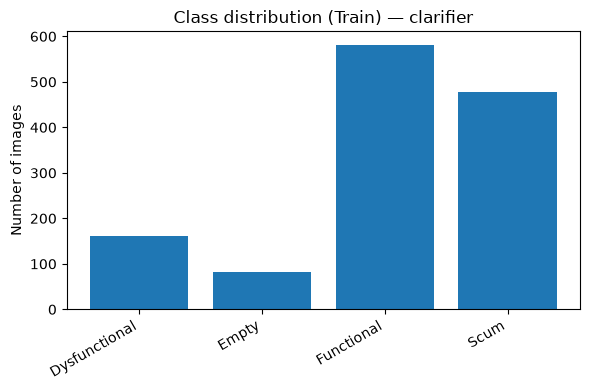

In [167]:
counts = np.bincount([label for _, label in train_ds.samples], minlength=num_classes)
for name, count in zip(class_names, counts):
    print(f"  {name:15s}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts)
plt.ylabel("Number of images")
plt.title(f"Class distribution (Train) — {COMPONENT}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

<h1>Split data</h1>

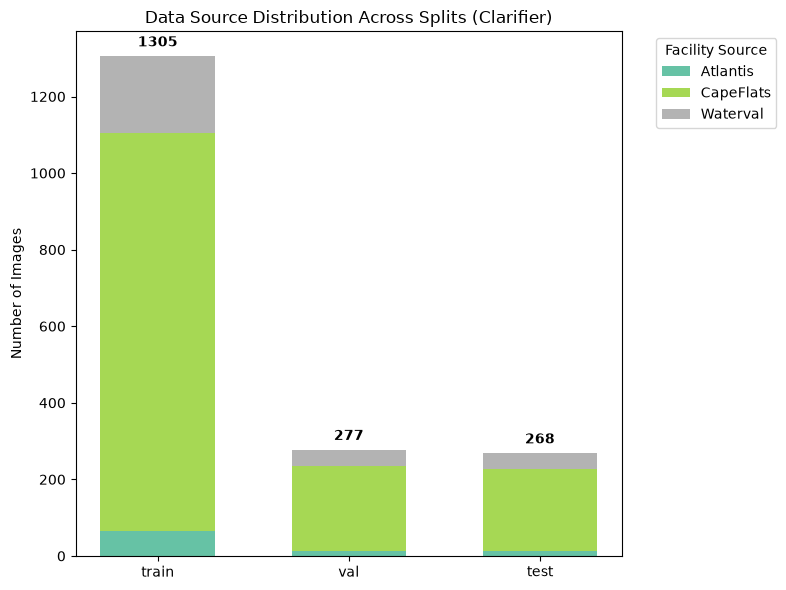

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

data_dir = DATASET_ROOT / COMPONENT 

splits = ['train', 'val', 'test']
split_facility_counts = {split: defaultdict(int) for split in splits}

for split in splits:
    split_dir = data_dir / split
    if not split_dir.exists():
        continue
        
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
            
        for img_path in class_dir.glob("*.*"):
            facility = img_path.name.split('_')[0]
            split_facility_counts[split][facility] += 1

all_facilities = sorted({
    facility 
    for split_data in split_facility_counts.values() 
    for facility in split_data.keys()
})

plot_data = {facility: [] for facility in all_facilities}

for split in splits:
    for facility in all_facilities:
        plot_data[facility].append(split_facility_counts[split].get(facility, 0))

fig, ax = plt.subplots(figsize=(8, 6))

bottoms = np.zeros(len(splits))

colors = plt.cm.Set2(np.linspace(0, 1, len(all_facilities)))

for idx, facility in enumerate(all_facilities):
    counts = np.array(plot_data[facility])
    ax.bar(splits, counts, label=facility, bottom=bottoms, color=colors[idx], width=0.6)
    bottoms += counts 

ax.set_ylabel('Number of Images')
ax.set_title(f'Data Source Distribution Across Splits ({COMPONENT.replace("_", " ").title()})')
ax.legend(title="Facility Source", bbox_to_anchor=(1.05, 1), loc='upper left')

for i, total in enumerate(bottoms):
    ax.text(i, total + (max(bottoms)*0.02), f'{int(total)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Inspect a batch

Quick sanity check that images and labels are loading correctly, and that
the rectangular resize looks right (no obvious squishing) before spending
time training.

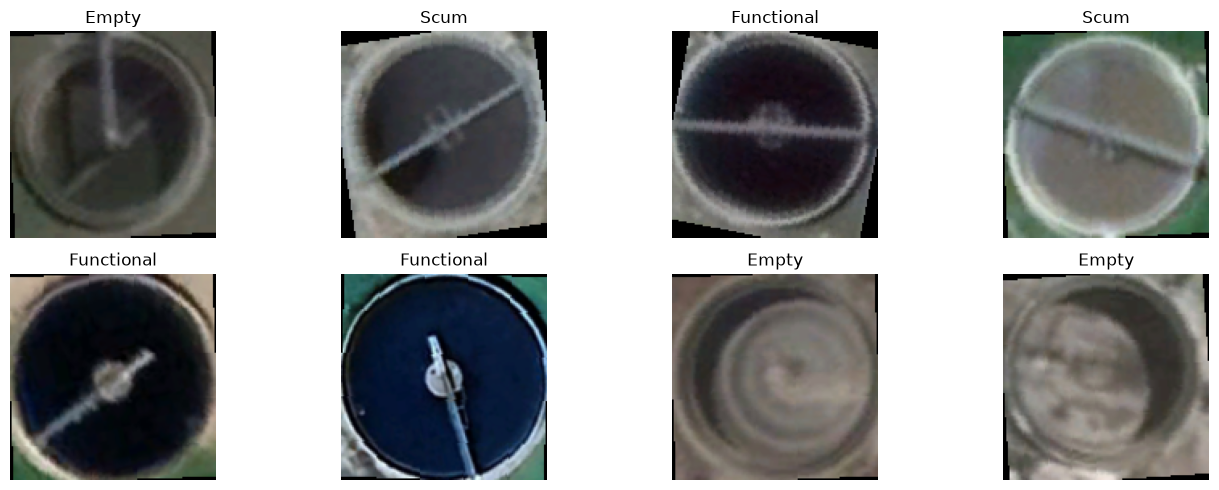

In [169]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

# 4. RESNET18


In [170]:
from torchvision import models
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ---------------------------------------------------------
# 4. Define the CNN (Transfer Learning with ResNet18)
# ---------------------------------------------------------

# Load the pre-trained ResNet18 backbone
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify the final fully connected layer to output our specific number of classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

# ---------------------------------------------------------
# 5. Instantiate loss and optimizer with Class Weights
# ---------------------------------------------------------

# Safely calculate class frequencies right here so we don't rely on outside variables
class_counts = np.bincount([label for _, label in train_ds.samples], minlength=num_classes)
class_counts_tensor = torch.tensor(class_counts, dtype=torch.float32)

# Calculate inverse frequency weights for the imbalanced classes
weights = 1.0 / class_counts_tensor

# Normalize weights so they sum to the number of classes (keeps loss magnitude stable)
weights = weights / weights.sum() * num_classes
class_weights = weights.to(device)

print(f"Applying class weights to loss function:")
for name, w in zip(class_names, weights.numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# Instantiate the scheduler
# mode='min' because we want to minimize loss
# factor=0.5 will halve the learning rate when triggered
# patience=3 waits 3 epochs with no improvement before reducing the LR
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.121
  Empty          : 2.187
  Functional     : 0.312
  Scum           : 0.380


# 5. Training loop, with early stopping

Given that overfitting showed up around epoch 50 in the previous run, this
version tracks validation loss each epoch and keeps the best-performing model
state in memory. Training stops automatically once val loss hasn't improved
for `EARLY_STOP_PATIENCE` epochs in a row, so you don't need to guess the
right epoch count up front — `EPOCHS` just acts as an upper bound.

In [171]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if train_mode:
                optimizer.zero_grad()

            y_hat = model(images)
            loss = criterion(y_hat, labels)

            if train_mode:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (y_hat.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    flag = " *" if improved else ""
    
    print(f"Epoch {epoch:3d}/{EPOCHS} | LR: {current_lr:.2e} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}{flag}")

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nNo val loss improvement for {EARLY_STOP_PATIENCE} epochs — stopping early at epoch {epoch}.")
        break

# Restore the best checkpoint
model.load_state_dict(best_model_state)
print(f"\nRestored model from best epoch (val loss = {best_val_loss:.4f})")

Epoch   1/100 | LR: 5.00e-04 | train loss 0.9059 acc 0.589 | val loss 1.4180 acc 0.639 *
Epoch   2/100 | LR: 5.00e-04 | train loss 0.5512 acc 0.751 | val loss 1.5822 acc 0.632
Epoch   3/100 | LR: 5.00e-04 | train loss 0.4612 acc 0.771 | val loss 1.0316 acc 0.671 *
Epoch   4/100 | LR: 5.00e-04 | train loss 0.3850 acc 0.807 | val loss 1.0403 acc 0.628
Epoch   5/100 | LR: 5.00e-04 | train loss 0.2996 acc 0.845 | val loss 0.7553 acc 0.740 *
Epoch   6/100 | LR: 5.00e-04 | train loss 0.2729 acc 0.864 | val loss 0.8528 acc 0.718
Epoch   7/100 | LR: 5.00e-04 | train loss 0.2805 acc 0.876 | val loss 1.2768 acc 0.657
Epoch   8/100 | LR: 5.00e-04 | train loss 0.2527 acc 0.882 | val loss 0.7834 acc 0.758
Epoch   9/100 | LR: 2.50e-04 | train loss 0.2555 acc 0.878 | val loss 1.2684 acc 0.617
Epoch  10/100 | LR: 2.50e-04 | train loss 0.1990 acc 0.909 | val loss 0.8676 acc 0.765
Epoch  11/100 | LR: 2.50e-04 | train loss 0.1364 acc 0.936 | val loss 0.8097 acc 0.773
Epoch  12/100 | LR: 2.50e-04 | train 

## Training curves

The vertical line marks the epoch that was restored (lowest validation
loss). Everything past that point is where the model was starting to
overfit.

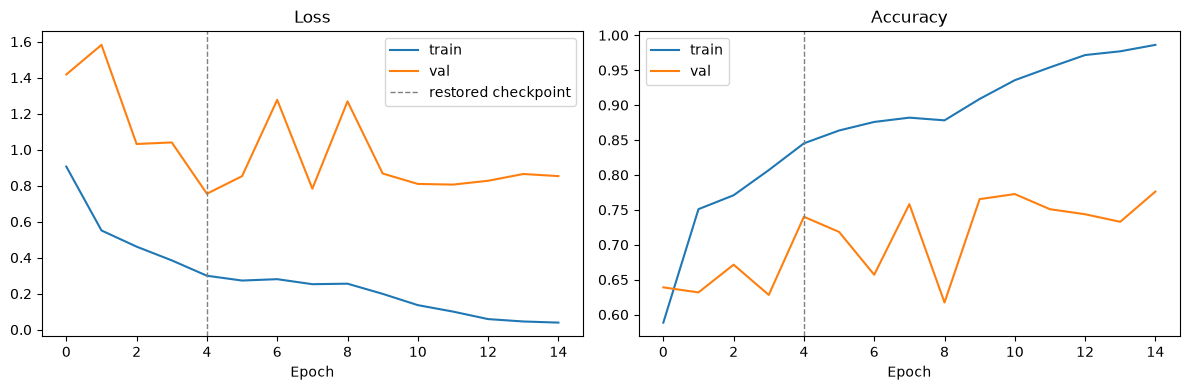

In [172]:
best_epoch = int(np.argmin(history["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].axvline(best_epoch - 1, color="gray", linestyle="--", linewidth=1, label="restored checkpoint")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].axvline(best_epoch - 1, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# 7. Evaluate on the test set

Test set was held out entirely from training/validation, so this gives an
unbiased read on final performance, using the restored best checkpoint rather
than whichever epoch training happened to stop on. The confusion matrix is
worth reading closely here — for this problem, false "Functional" calls on a
genuinely Dysfunctional unit matter more than the reverse, so it's worth
checking which direction the model's mistakes lean.

Test accuracy: 0.690


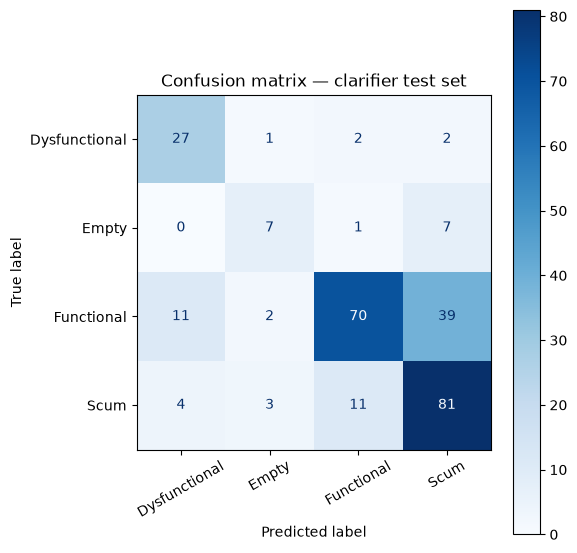

In [173]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_hat = model(images)
        preds = y_hat.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy: {test_acc:.3f}")

# Force the matrix to build a grid for all known classes using their integer indices (0 to 3)
cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix — {COMPONENT} test set")
plt.tight_layout()
plt.show()

## Per-class precision, recall, and F1

The confusion matrix shows *where* mistakes happen; this breaks it down into
per-class numbers. Recall matters most for the "Dysfunctional" class in
particular — missing a genuinely dysfunctional unit (low recall) is a worse
failure mode for this application than a false alarm (low precision).

In [174]:
from sklearn.metrics import classification_report

# Added 'labels' to define the 4x4 structure, and 'zero_division' to suppress warnings for the Empty class
print(classification_report(
    all_labels, 
    all_preds, 
    labels=range(len(class_names)), 
    target_names=class_names, 
    digits=3, 
    zero_division=0
))

               precision    recall  f1-score   support

Dysfunctional      0.643     0.844     0.730        32
        Empty      0.538     0.467     0.500        15
   Functional      0.833     0.574     0.680       122
         Scum      0.628     0.818     0.711        99

     accuracy                          0.690       268
    macro avg      0.661     0.676     0.655       268
 weighted avg      0.718     0.690     0.687       268



## ROC curves and Area Under the Curve (AUC)

Since this is a multi-class problem, each class gets its own one-vs-rest
curve: "this class" vs. "everything else," using the model's predicted
probability for that class.

An ROC curve is generated by sweeping the decision threshold across the full
range of predicted probabilities and, at each point, plotting **sensitivity**
(true positive rate — of the actual positives, how many did we catch) against
**1 - specificity** (false positive rate — of the actual negatives, how many
did we wrongly flag). This is the standard ROC curve, as opposed to a
precision-recall curve. **AUC**, shown in the legend, is the area under that
curve: a single threshold-free number summarizing performance across every
possible cutoff. 0.5 means no better than random guessing, 1.0 is a perfect
classifier for that class.

This needs raw probabilities (not just the predicted class), so the test set
is passed through the model again to collect them.

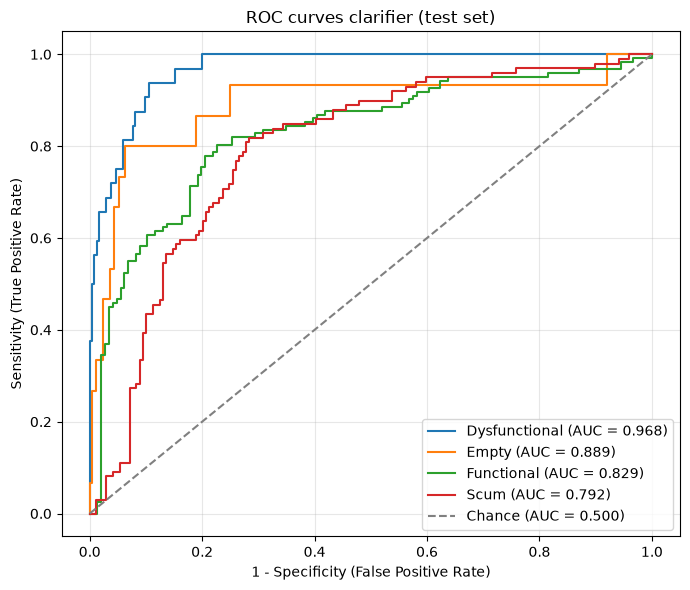

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.968
  Empty          : 0.889
  Functional     : 0.829
  Scum           : 0.792

Mean AUC: 0.869


In [175]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

model.eval()
all_probs = []
all_labels_full = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_hat = model(images)
        probs = torch.softmax(y_hat, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels_full.extend(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels_full = np.array(all_labels_full)

# One-vs-rest binarized labels: one column per class, 1 if that's the true class
y_true_bin = label_binarize(all_labels_full, classes=list(range(num_classes)))

plt.figure(figsize=(7, 6))
roc_aucs = {}

for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], all_probs[:, i])
    roc_aucs[name] = auc
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance (AUC = 0.500)")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title(f"ROC curves {COMPONENT} (test set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("AUC (area under ROC curve) per class:")
for name, auc in roc_aucs.items():
    print(f"  {name:15s}: {auc:.3f}")
print(f"\nMean AUC: {np.mean(list(roc_aucs.values())):.3f}")


# 8. Save the trained model

In [176]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "img_target_size": IMG_TARGET_SIZE,
    "component": COMPONENT,
}, MODEL_SAVE_PATH)

print(f"Saved model to {MODEL_SAVE_PATH}")

Saved model to ../models/clarifier_cnn.pt
